In [1]:
import torch
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from natsort import natsorted

In [2]:
path = "/home/huang717/DRAGN/IRM/injectable-alignment-model/runs/Llama-2-7b-chat-hf_anger_60k_31_training_latest/results/Llama-2-7b-chat-hf_anger_60k_31_inference/Prompt1_CSVs"

In [3]:
# Dictionary to store DataFrames from CSV files
data = dict()
# List to track CSV file identifiers for ordered processing
csv_identifiers = []
csv_counter = 1

# Check if the provided path is a directory
if os.path.isdir(path):
    print("Path: ", path, flush=True)
    
    # Get and sort files using natural sorting (handles numbers in filenames properly)
    files = os.listdir(path)
    files = natsorted(files)  # Natural sort handles "file10" coming after "file9" correctly

    # Those files would be "generated_token_x.csv" or "prompt_token_x.csv"
    for file in files:
        file_path = os.path.join(path, file)
        
        # If it's a directory, recursively process it, which never happens I guess
        if os.path.isdir(file_path):
            print('This is a directory!')
        else:
            # print("File: ", file, flush=True)
        
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)
            
            # Add a 'csv_number' column to track the source file
            # This helps correlate visualizations back to specific tokens
            df['csv_number'] = csv_counter
            
            # Store the DataFrame in our dictionary, using filename as key
            data[file] = df
            
            # Keep track of the identifier for ordering
            csv_identifiers.append(csv_counter)
            csv_counter += 1

Path:  /home/huang717/DRAGN/IRM/injectable-alignment-model/runs/Llama-2-7b-chat-hf_anger_60k_31_training_latest/results/Llama-2-7b-chat-hf_anger_60k_31_inference/Prompt1_CSVs


In [2]:
def generate_average_generated_token_heatmap(directory_path, output_path=None, save=False):
    """
    Generates a heatmap showing the average activation values across 
    the first 10 generated tokens only.
    
    This function is completely standalone and can be run independently
    of the tensor_logger.py file.
    
    Args:
        directory_path (str): Directory path containing CSV files with IRM activation data
        output_path (str, optional): Directory to save the output heatmap. 
                                    If None, uses directory_path.
    
    Returns:
        pandas.DataFrame: The pivoted dataframe used to generate the heatmap
    """
    # Set output path to input path if not specified
    if output_path is None:
        output_path = directory_path
    
    # Find all generated token CSV files
    generated_files = []
    
    # Check if path is a directory
    if os.path.isdir(directory_path):
        # Get all files and sort them naturally
        files = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]
        files = natsorted(files)
        
        # Identify generated token files
        for file in files:
            if "generated" in file:
                generated_files.append(os.path.join(directory_path, file))
    
    # Take only the first N generated files
    n = 20
    generated_files = generated_files[:n]
    
    if not generated_files:
        print("No generated token files found in directory:", directory_path)
        return None
    
    print(f"Using {len(generated_files)} generated token files for average heatmap.")
    
    # Load and process the files
    dataframes = []
    for file in generated_files:
        try:
            df = pd.read_csv(file)
            dataframes.append(df)
            print(f"Loaded file: {os.path.basename(file)}")
        except Exception as e:
            print(f"Error loading file {file}: {e}")
    
    if not dataframes:
        print("No valid CSV files could be loaded.")
        return None
    
    # Combine all DataFrames and calculate average by layer and index
    combined_df = pd.concat(dataframes)
    average_df = combined_df.groupby(['layer', 'index'])['value'].mean().reset_index()
    
    # Pivot data for heatmap format
    pivot_df = average_df.pivot(index="layer", columns="index", values="value")
    
    # Fill NaN values with zeros
    pivot_df_filled = pivot_df.fillna(0)
    
    # Calculate min/max for color scaling
    min_val = pivot_df_filled.min().min()
    max_val = pivot_df_filled.max().max()
    
    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)
    
    # Generate the heatmap visualization
    plt.figure(figsize=(14, 8))
    ax = sns.heatmap(
        pivot_df_filled, 
        cmap="cividis", 
        cbar_kws={'label': 'Average Activation Value'},
        center=0.0,
        vmin=min_val,
        vmax=max_val
    )
    
    # Set up custom tick marks for better readability
    # Create tick marks at regular intervals
    max_index = pivot_df_filled.columns.max() if len(pivot_df_filled.columns) > 0 else 0
    xticks = [i for i in range(0, max_index + 1, 128) if i <= max_index]
    xticklabels = [i if i % 512 == 0 else "" for i in xticks]
    
    # Set ticks for layers
    layers = sorted(pivot_df_filled.index.unique())
    yticks = np.arange(len(layers))
    yticklabels = layers
    
    # Apply ticks
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)
    
    # Add title and labels
    plt.title(f"Average Activation Values (First {n} Generated Tokens Only)")
    plt.xlabel("Token Position Index")
    plt.ylabel("Layer")
    
    # Save the heatmap
    heatmap_file_name = f"average_first_{n}_generated_tokens_heatmap.png"
    output_file_path = os.path.join(output_path, heatmap_file_name)
    if save:
        plt.savefig(output_file_path)
    plt.close()
    
    print(f"Generated heatmap saved as: {output_file_path}")
    return average_df, pivot_df_filled  # Return the data for further analysis if needed

In [ ]:
prompt_idx = 1
angry_path = f"/home/huang717/DRAGN/IRM/injectable-alignment-model/runs/with_regularization/Anger60k_L1_on_outputs_irm_layer_31/results/Llama-2-7b-chat-hf_anger_60k_31_inference/Prompt{prompt_idx}_CSVs"
sadness_path = f"/home/huang717/DRAGN/IRM/injectable-alignment-model/runs/with_regularization/Sadness60k_L1_on_outputs_irm_layer_31/results/Llama-2-7b-chat-hf_sadness_60k_31_inference/Prompt{prompt_idx}_CSVs"
neutral_path = f"/home/huang717/DRAGN/IRM/injectable-alignment-model/runs/with_regularization/Neutral60k_L1_on_outputs_irm_layer_31/results/Llama-2-7b-chat-hf_neutral_60k_31_inference/Prompt{prompt_idx}_CSVs"
output_file_path = f"/home/huang717/DRAGN/IRM/injectable-alignment-model/src/utils"

In [4]:
angry_avg_csv = generate_average_generated_token_heatmap(angry_path, output_file_path)[0]
sadness_avg_csv = generate_average_generated_token_heatmap(sadness_path, output_file_path)[0]
neutral_avg_csv = generate_average_generated_token_heatmap(neutral_path, output_file_path)[0]

Using 20 generated token files for average heatmap.
Loaded file: generated_token_1.csv
Loaded file: generated_token_2.csv
Loaded file: generated_token_3.csv
Loaded file: generated_token_4.csv
Loaded file: generated_token_5.csv
Loaded file: generated_token_6.csv
Loaded file: generated_token_7.csv
Loaded file: generated_token_8.csv
Loaded file: generated_token_9.csv
Loaded file: generated_token_10.csv
Loaded file: generated_token_11.csv
Loaded file: generated_token_12.csv
Loaded file: generated_token_13.csv
Loaded file: generated_token_14.csv
Loaded file: generated_token_15.csv
Loaded file: generated_token_16.csv
Loaded file: generated_token_17.csv
Loaded file: generated_token_18.csv
Loaded file: generated_token_19.csv
Loaded file: generated_token_20.csv
Generated heatmap saved as: /home/huang717/DRAGN/IRM/injectable-alignment-model/src/utils/average_first_20_generated_tokens_heatmap.png
Using 20 generated token files for average heatmap.
Loaded file: generated_token_1.csv
Loaded file: g

In [5]:
combined_df = pd.concat([angry_avg_csv, sadness_avg_csv, neutral_avg_csv])
mean_of_3 = combined_df.groupby(['layer', 'index'])['value'].mean().reset_index()

In [6]:
rounded_mean_of_3 = mean_of_3.copy()
rounded_mean_of_3['value'] = rounded_mean_of_3['value'].round(0)

In [7]:
mean_of_3, rounded_mean_of_3

(      layer  index     value
 0        31      0 -0.000122
 1        31      1 -0.000087
 2        31      2  0.000012
 3        31      3  0.000069
 4        31      4  0.000129
 ...     ...    ...       ...
 4091     31   4091 -0.000151
 4092     31   4092 -0.000187
 4093     31   4093 -0.000019
 4094     31   4094 -0.000128
 4095     31   4095 -0.000225
 
 [4096 rows x 3 columns],
       layer  index  value
 0        31      0   -0.0
 1        31      1   -0.0
 2        31      2    0.0
 3        31      3    0.0
 4        31      4    0.0
 ...     ...    ...    ...
 4091     31   4091   -0.0
 4092     31   4092   -0.0
 4093     31   4093   -0.0
 4094     31   4094   -0.0
 4095     31   4095   -0.0
 
 [4096 rows x 3 columns])

In [8]:
# def plot_heatmap(df, title=None):
#     # Pivot data for heatmap format
#     pivot_df = df.pivot(index="layer", columns="index", values="value")

#     # Fill NaN values with zeros
#     pivot_df_filled = pivot_df.fillna(0)

#     # Calculate min/max for color scaling
#     min_val = pivot_df_filled.min().min()
#     max_val = pivot_df_filled.max().max()


#     # Generate the heatmap visualization
#     plt.figure(figsize=(14, 8))
#     ax = sns.heatmap(
#         pivot_df_filled, 
#         cmap="vlag", 
#         cbar_kws={'label': 'Average Activation Value'},
#         center=0.0,
#         vmin=min_val,
#         vmax=max_val
#     )

#     # Set up custom tick marks for better readability
#     # Create tick marks at regular intervals
#     max_index = pivot_df_filled.columns.max() if len(pivot_df_filled.columns) > 0 else 0
#     xticks = [i for i in range(0, max_index + 1, 128) if i <= max_index]
#     xticklabels = [i if i % 512 == 0 else "" for i in xticks]

#     # Set ticks for layers
#     layers = sorted(pivot_df_filled.index.unique())
#     yticks = np.arange(len(layers))
#     yticklabels = layers

#     # Apply ticks
#     ax.set_xticks(xticks)
#     ax.set_xticklabels(xticklabels)
#     ax.set_yticks(yticks)
#     ax.set_yticklabels(yticklabels)

#     # Add title and labels
#     if title:
#         plt.title(title)
#     plt.xlabel("Token Position Index")
#     plt.ylabel("Layer")
#     plt.show()

def plot_heatmap(df, title=None):
    # Pivot data for heatmap format
    pivot_df = df.pivot(index="layer", columns="index", values="value")

    # Fill NaN values with zeros
    pivot_df_filled = pivot_df.fillna(0)

    # Calculate min/max for color scaling
    min_val = pivot_df_filled.min().min()
    max_val = pivot_df_filled.max().max()
    
    # Find the max absolute value for symmetric color scaling
    abs_max = max(abs(min_val), abs(max_val))
    
    # Create a custom diverging palette (blue to white to red)
    # 220 is blue, 20 is red in hue values
    custom_cmap = sns.diverging_palette(220, 20, as_cmap=True)
    # custom_cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)

    ticks = np.linspace(-abs_max, abs_max, 7)

    # Generate the heatmap visualization
    plt.figure(figsize=(100, 8))
    ax = plt.gca()
    sns.heatmap(
        pivot_df_filled, 
        cmap='coolwarm',  # Use the custom diverging colormap
        cbar_kws={'label': 'Average Activation Value',
            'ticks': ticks,  # Specify the ticks you want to show
            'format': '%.2f'  # Format the tick labels
            },
        center=0.0,
        vmin=-abs_max,
        vmax=abs_max,
        # vmin=min_val,
        # vmax=max_val,
        ax = ax
    )
    # ax.set_aspect(0.1)

    # Set up custom tick marks for better readability
    max_index = pivot_df_filled.columns.max() if len(pivot_df_filled.columns) > 0 else 0
    xticks = [i for i in range(0, max_index + 1, 128) if i <= max_index]
    xticklabels = [i if i % 128 == 0 else "" for i in xticks]

    # Set ticks for layers
    layers = sorted(pivot_df_filled.index.unique())
    yticks = np.arange(len(layers))
    yticklabels = layers

    # Apply ticks
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)

    # Add title and labels
    if title:
        plt.title(title)
    plt.xlabel("Token Position Index")
    plt.ylabel("Layer")
    plt.show()

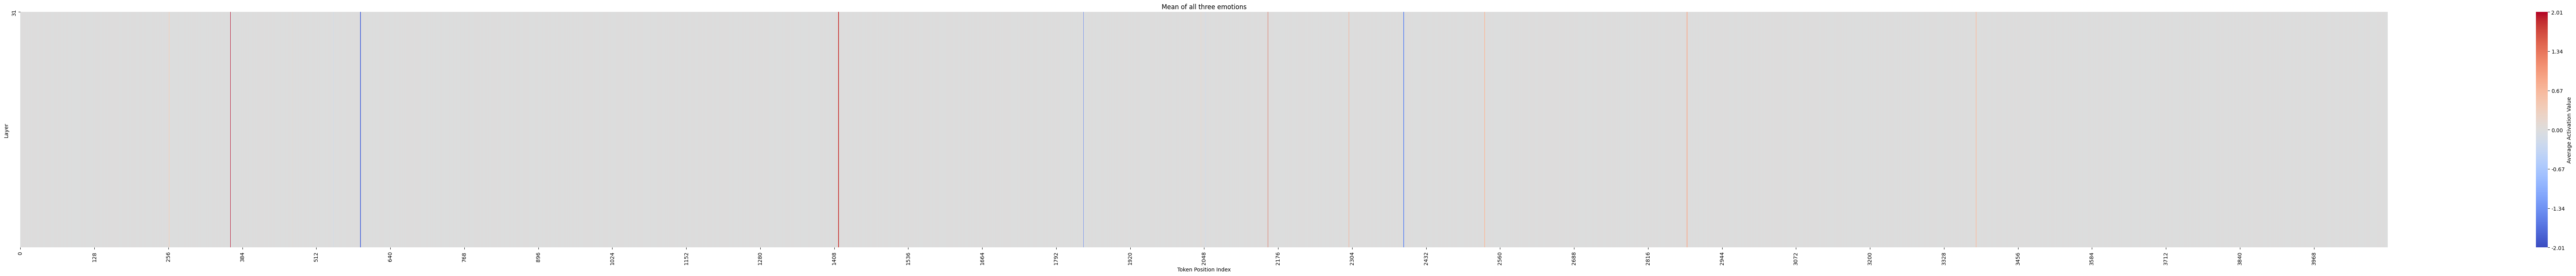

      layer  index     value
363      31    363  2.006227
588      31    588 -1.710762
1415     31   1415  1.788862
1839     31   1839 -1.361667
2158     31   2158  1.476006
2298     31   2298  0.874745
2393     31   2393 -1.414864
2533     31   2533  0.594012
2883     31   2883  0.808783
3383     31   3383  0.518571


In [ ]:
plot_heatmap(mean_of_3, title="Mean of all three emotions")
non_zero_rows = mean_of_3[abs(mean_of_3['value']) >= 0.5]
print(non_zero_rows)
non_zero_rows.to_csv('mean_of_3')

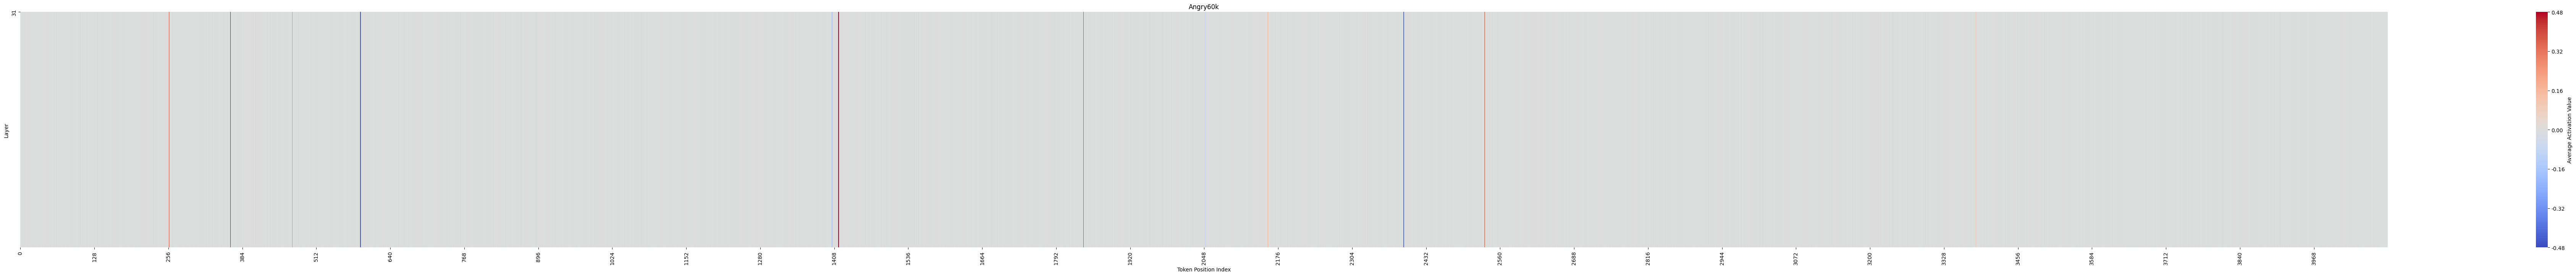

      layer  index     value
363      31    363  0.474211
588      31    588 -0.467800
1415     31   1415  0.476815
1839     31   1839 -0.426375
2393     31   2393 -0.403627


In [44]:
plot_heatmap(angry_avg_csv, title="Angry60k")
non_zero_rows = angry_avg_csv[abs(angry_avg_csv['value']) >= 0.4]
print(non_zero_rows)

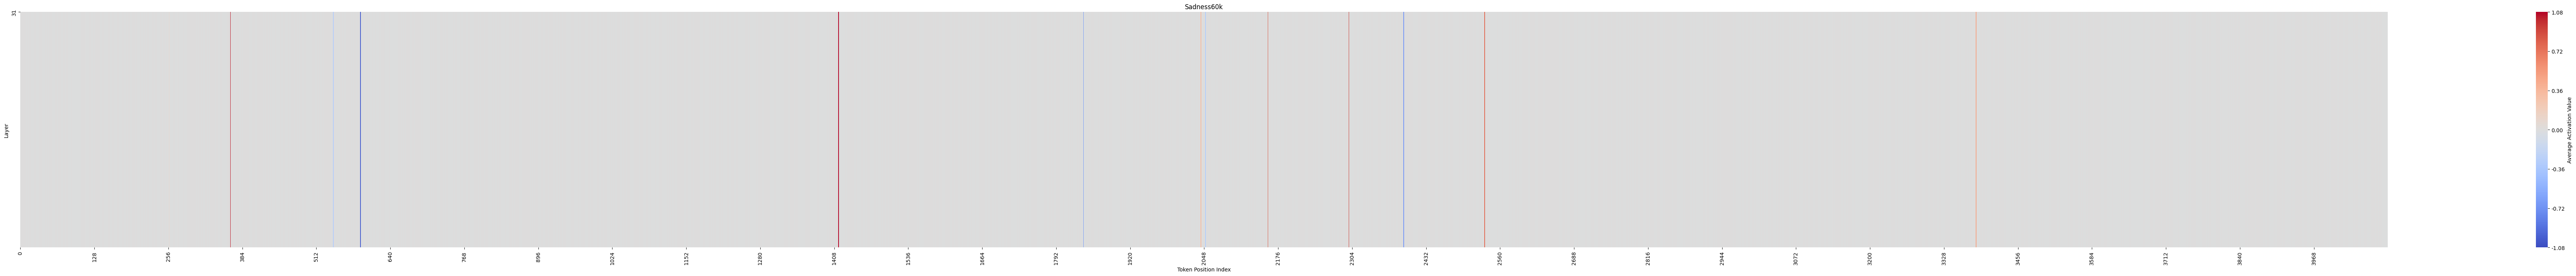

      layer  index     value
363      31    363  1.031144
588      31    588 -0.996993
1415     31   1415  1.076746
1839     31   1839 -0.660796
2158     31   2158  0.824102
2298     31   2298  0.935845
2393     31   2393 -0.685945
2533     31   2533  0.770267
3383     31   3383  0.472841


In [50]:
plot_heatmap(sadness_avg_csv, title="Sadness60k")
non_zero_rows = sadness_avg_csv[abs(sadness_avg_csv['value']) >= 0.4]
print(non_zero_rows)

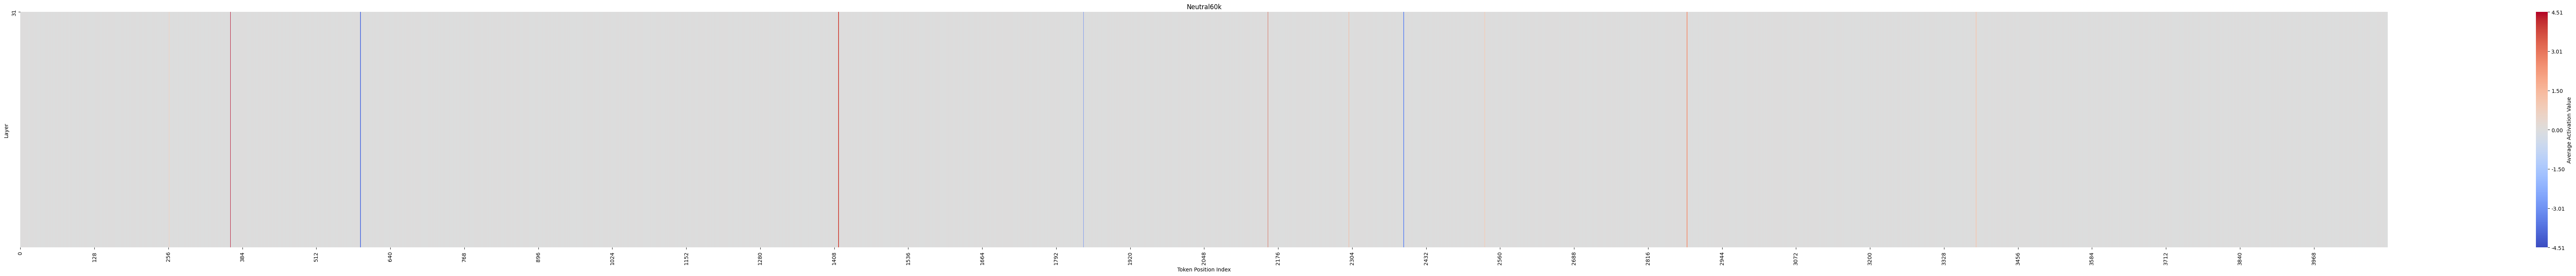

      layer  index     value
363      31    363  4.513327
588      31    588 -3.667494
1415     31   1415  3.813024
1839     31   1839 -2.997830
2158     31   2158  3.417875
2298     31   2298  1.688327
2393     31   2393 -3.155021
2883     31   2883  2.425981
3383     31   3383  1.000362


In [51]:
plot_heatmap(neutral_avg_csv, title="Neutral60k")
non_zero_rows = neutral_avg_csv[abs(neutral_avg_csv['value']) >= 1]
print(non_zero_rows)

In [47]:
def subtract_2_from_1(df1, df2):
    df2_dict = dict(zip(zip(df2['layer'], df2['index']), df2['value']))
    df1_minus_df2 = df1.copy()
    df1_minus_df2['value'] = df1.apply(
        lambda row: row['value'] - df2_dict.get((row['layer'], row['index']), 0), 
        axis=1
    )
    return df1_minus_df2

In [48]:
angry_minus_mean = subtract_2_from_1(angry_avg_csv, mean_of_3)
sadness_minus_mean = subtract_2_from_1(neutral_avg_csv, mean_of_3)
neutral_minus_mean = subtract_2_from_1(sadness_avg_csv, mean_of_3)

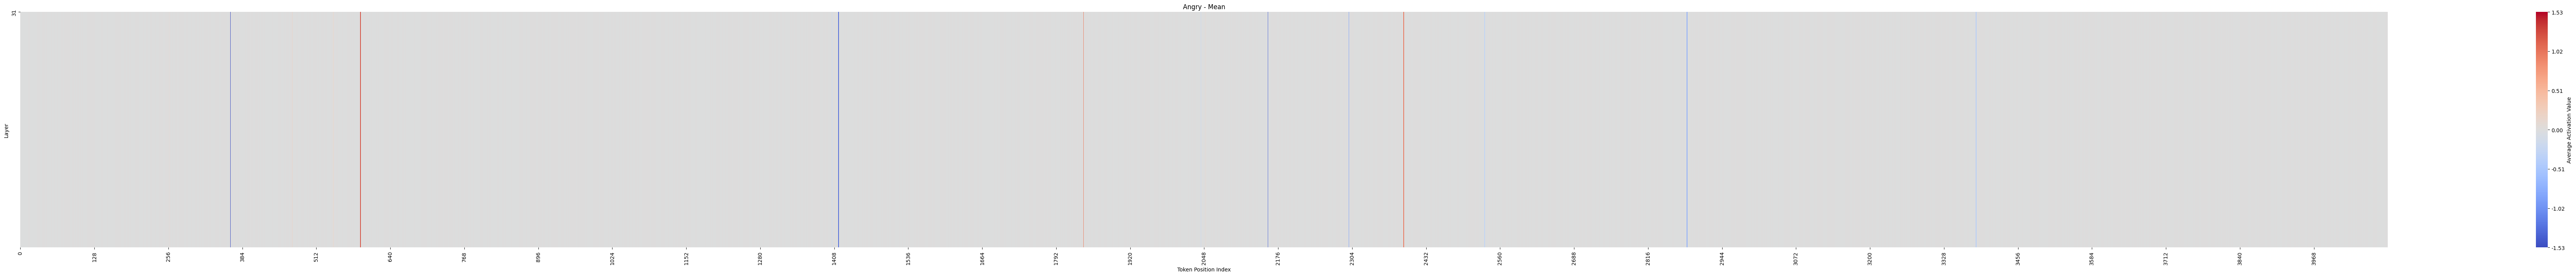

      layer  index     value
363      31    363 -1.532016
588      31    588  1.242962
1415     31   1415 -1.312047
1839     31   1839  0.935292
2158     31   2158 -1.289966
2298     31   2298 -0.874682
2393     31   2393  1.011237
2883     31   2883 -0.808853
3383     31   3383 -0.436060


In [52]:
plot_heatmap(angry_minus_mean, title="Angry - Mean")
non_zero_rows = angry_minus_mean[abs(angry_minus_mean['value']) >= 0.4]
print(non_zero_rows)

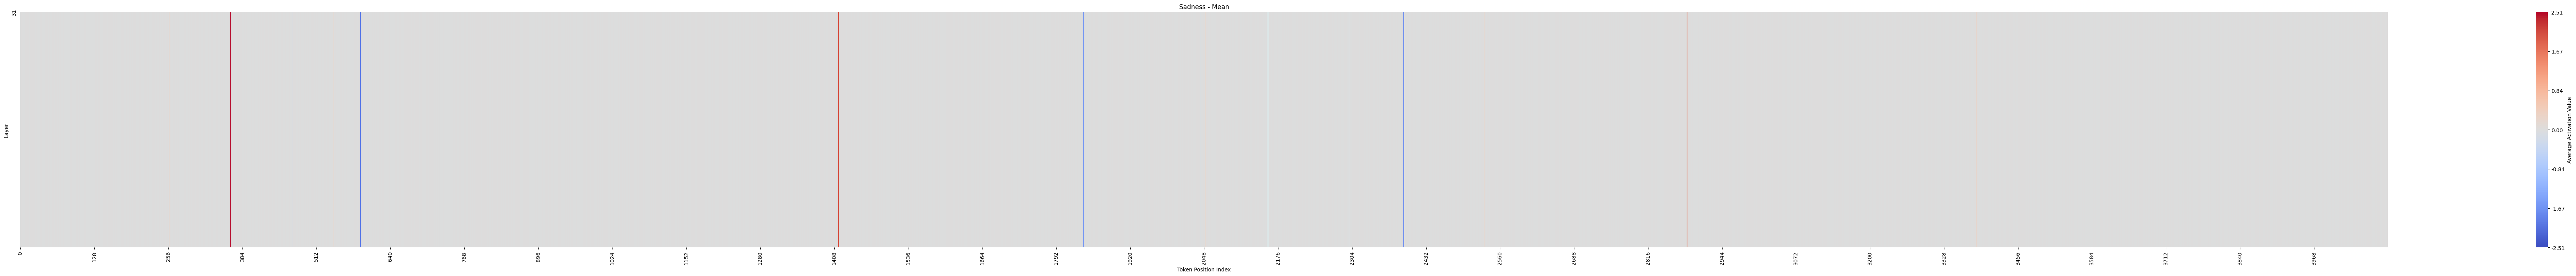

      layer  index     value
363      31    363  2.507100
588      31    588 -1.956731
1415     31   1415  2.024162
1839     31   1839 -1.636163
2158     31   2158  1.941870
2298     31   2298  0.813582
2393     31   2393 -1.740156
2883     31   2883  1.617198
3383     31   3383  0.481791


In [53]:
plot_heatmap(sadness_minus_mean, title="Sadness - Mean")
non_zero_rows = sadness_minus_mean[abs(sadness_minus_mean['value']) >= 0.4]
print(non_zero_rows)

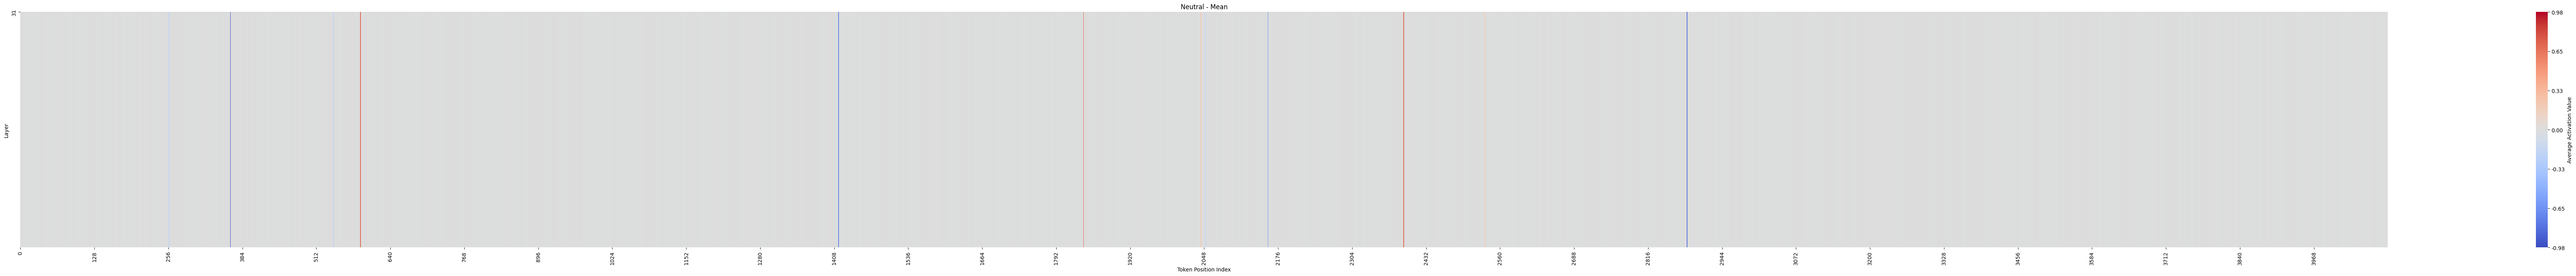

      layer  index     value
363      31    363 -0.975083
588      31    588  0.713769
1415     31   1415 -0.712116
1839     31   1839  0.700871
2158     31   2158 -0.651903
2393     31   2393  0.728919
2883     31   2883 -0.808346


In [54]:
plot_heatmap(neutral_minus_mean, title="Neutral - Mean")
non_zero_rows = neutral_minus_mean[abs(neutral_minus_mean['value']) >= 0.4]
print(non_zero_rows)

In [52]:
def value_stats(df, column_name):
    """
    Calculate statistics for positive and negative values in a DataFrame column.
    
    Parameters:
    df (pandas.DataFrame): The DataFrame to analyze
    column_name (str): The name of the column to analyze
    
    Returns:
    dict: Dictionary containing counts and means for positive and negative values
           {
               'positive_count': int,
               'positive_mean': float,
               'negative_count': int,
               'negative_mean': float
           }
    """
    # Get positive values
    positive_values = df[df[column_name] > 0][column_name]
    positive_count = len(positive_values)
    positive_mean = positive_values.mean()
    postive_median = positive_values.median()
    
    # Get negative values
    negative_values = df[df[column_name] < 0][column_name]
    negative_count = len(negative_values)
    negative_mean = negative_values.mean()
    negative_median = negative_values.median()
    
    # Return as dictionary for easy access
    return {
        'positive_count': positive_count,
        'positive_mean': positive_mean,
        'positive_median': postive_median,
        'negative_count': negative_count,
        'negative_mean': negative_mean,
        'negative_median': negative_median
    }

# Example usage:
# stats = value_stats(df, 'value')
# print(f"Positive values: {stats['positive_count']} (mean: {stats['positive_mean']:.4f})")
# print(f"Negative values: {stats['negative_count']} (mean: {stats['negative_mean']:.4f})")

In [53]:
angry_minus_mean_stats = value_stats(angry_minus_mean, 'value')
print(angry_minus_mean_stats)
sadness_minus_mean_stats = value_stats(sadness_minus_mean, 'value')
print(sadness_minus_mean_stats)
neutral_minus_mean_stats = value_stats(neutral_minus_mean, 'value')
print(neutral_minus_mean_stats)


{'positive_count': 2019, 'positive_mean': 0.001883436697069372, 'positive_median': 9.19467115e-05, 'negative_count': 2077, 'negative_mean': -0.003384697363715484, 'negative_median': -9.00734173e-05}
{'positive_count': 2056, 'positive_mean': 0.0050662154251292215, 'positive_median': 0.00015570391673775, 'negative_count': 2040, 'negative_mean': -0.0029299226651326588, 'negative_median': -0.000149746199345}
{'positive_count': 2026, 'positive_mean': 0.001430725678730113, 'positive_median': 8.433100842908333e-05, 'negative_count': 2070, 'negative_mean': -0.0019856952508445756, 'negative_median': -8.478776329933334e-05}
